In [61]:
# ============================================================
# Notebook 03: Performance Evaluation & Clinical Metrics
# Cell 1: Setup and Libraries
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms

from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [62]:
import os
import torch

# ============================================================
# DIAGNOSTIC CODE: Check Folder Image Count & Model Classes
# ============================================================

# Paths to your model weights and test directory
MODEL_WEIGHT_PATH = r"/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/pneumoxnet_best.pth"
TEST_DIR = r"/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test"

# 1. Check the number of output classes in the saved model
checkpoint = torch.load(MODEL_WEIGHT_PATH, map_location="cpu")
state_dict = (
    checkpoint.get("model_state_dict", checkpoint)
    if isinstance(checkpoint, dict)
    else checkpoint
)

print("==================================================")
for k, v in state_dict.items():
    if "classifier" in k and "weight" in k:
        print(f"--> Saved model weight shape: {v.shape}")
        print(f"--> Number of output classes in your saved model: {v.shape[0]}")

# 2. Count the actual number of images in each test folder
print("\n--> Number of actual images in your test folder:")
for subfolder in os.listdir(TEST_DIR):
    sub_path = os.path.join(TEST_DIR, subfolder)
    if os.path.isdir(sub_path):
        files = [
            f
            for f in os.listdir(sub_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        print(f"    - {subfolder}: {len(files)} images")
print("==================================================")



--> Saved model weight shape: torch.Size([1408])
--> Number of output classes in your saved model: 1408
--> Saved model weight shape: torch.Size([512, 1408])
--> Number of output classes in your saved model: 512
--> Saved model weight shape: torch.Size([512])
--> Number of output classes in your saved model: 512
--> Saved model weight shape: torch.Size([2, 512])
--> Number of output classes in your saved model: 2

--> Number of actual images in your test folder:
    - BACTERIA: 417 images
    - NORMAL: 238 images
    - VIRUS: 224 images


In [63]:
import os

print("=== DEEP WORKSPACE FILE SCAN ===")
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir) if os.path.basename(current_dir) == "notebooks" else current_dir

print(f"Scanning root directory: {parent_dir}\n")

found_weights = []
found_test = []

for root, dirs, files in os.walk(parent_dir):
    for f in files:
        if f.endswith('.pt') or f.endswith('.pth'):
            full_p = os.path.join(root, f)
            found_weights.append(full_p)
            print(f"FOUND WEIGHT FILE: {full_p}")
            
    if "test" in os.path.basename(root).lower():
        sub_folders = [d.upper() for d in dirs]
        if "NORMAL" in sub_folders or "PNEUMONIA" in sub_folders:
            found_test.append(root)
            print(f"FOUND TEST DIR:    {root}")

if not found_weights:
    print("NO .pt or .pth files found anywhere in the project tree!")

=== DEEP WORKSPACE FILE SCAN ===
Scanning root directory: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI

FOUND TEST DIR:    /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/best_model.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/convnexttiny_260px_best.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/convnext_tiny_best.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/convnext_tiny_checkpoint.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/efficientnet_b2_best.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/efficientnet_b2_checkpoint.pth
FOUND WEIGHT FILE: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/

In [64]:
import os
from pathlib import Path

print("==================================================")
print("       AUTOMATED DIRECTORY SEARCH TOOL            ")
print("==================================================")

current_dir = os.getcwd()
print(f"Scanning Working Directory: {current_dir}\n")

found_weights = []
found_test_dirs = []

# Scan for files and folders recursively
for root, dirs, files in os.walk(current_dir):
    # 1. Search for Model Weight Files
    for file in files:
        if file.endswith(".pt") or file.endswith(".pth"):
            rel_path = os.path.relpath(os.path.join(root, file), current_dir)
            found_weights.append(rel_path)
            
    # 2. Search for Test Folder
    if "test" in os.path.basename(root).lower():
        sub_folders = [d.upper() for d in dirs]
        if "NORMAL" in sub_folders or "PNEUMONIA" in sub_folders:
            rel_path = os.path.relpath(root, current_dir)
            found_test_dirs.append(rel_path)

print("--- [1] FOUND MODEL WEIGHT FILES ---")
if found_weights:
    for idx, w_path in enumerate(found_weights, 1):
        print(f"  ({idx}) {w_path}")
else:
    print("  No .pt or .pth files found in this workspace.")

print("\n--- [2] FOUND TEST DATASET FOLDERS ---")
if found_test_dirs:
    for idx, t_path in enumerate(found_test_dirs, 1):
        print(f"  ({idx}) {t_path}")
else:
    print("  No test dataset directory containing 'NORMAL'/'PNEUMONIA' found.")

print("==================================================")

       AUTOMATED DIRECTORY SEARCH TOOL            
Scanning Working Directory: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI

--- [1] FOUND MODEL WEIGHT FILES ---
  (1) models/best_model.pth
  (2) models/convnexttiny_260px_best.pth
  (3) models/convnext_tiny_best.pth
  (4) models/convnext_tiny_checkpoint.pth
  (5) models/efficientnet_b2_best.pth
  (6) models/efficientnet_b2_checkpoint.pth
  (7) models/pneumoxnet_best.pth
  (8) models/pneumoxnet_best_by_loss.pth
  (9) models/pneumoxnet_checkpoint.pth
  (10) models/resnet50_260px_best.pth
  (11) models/resnet50_best.pth
  (12) models/resnet50_checkpoint.pth

--- [2] FOUND TEST DATASET FOLDERS ---
  (1) dataset/processed_dataset/test


In [65]:
# ============================================================
# Cell 2: Configuration Parameters
# ============================================================
import os
from pathlib import Path

IMAGE_SIZE = 224

# Exact paths detected by workspace scan
MODEL_WEIGHT_PATH = r"/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/pneumoxnet_best.pth"
TEST_DIR = r"/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test"

OUTPUT_DIR = Path("evaluation_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

print(f"Model File Exists: {os.path.exists(MODEL_WEIGHT_PATH)}")
print(f"Test Folder Exists: {os.path.exists(TEST_DIR)}")
print("Cell 2: Configurations initialized successfully.")

Model File Exists: True
Test Folder Exists: True
Cell 2: Configurations initialized successfully.


In [66]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transform)

# Print class mappings to verify:
print("Dataset class to idx:", test_dataset.class_to_idx) 
# Expected output: {'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}

Dataset class to idx: {'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}


In [67]:
# ============================================================
# Cell 3: PneumoXNet Model Loading (Fixed 2-Class)
# ============================================================
import torch
import torch.nn as nn
import timm

class PneumoXNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=False, dropout_rate=0.4):
        super(PneumoXNet, self).__init__()
        self.backbone = timm.create_model('tf_efficientnet_b2.ns_jft_in1k', pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

# Initialize Architecture with exactly 2 classes
model = PneumoXNet(num_classes=2, pretrained=False).to(device)

# Load Saved Weights
checkpoint = torch.load(MODEL_WEIGHT_PATH, map_location=device)
state_dict = checkpoint.get('model_state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint

model.load_state_dict(state_dict)
model.eval()
print("Cell 3: Model successfully loaded as 2-Class Classifier (Normal vs Pneumonia).")

Cell 3: Model successfully loaded as 2-Class Classifier (Normal vs Pneumonia).


In [68]:
# ============================================================
# Cell 4: Fixed DataLoader & Inference
# ============================================================
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds = []
all_probs = []
raw_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Running Test Inference"):
        inputs = inputs.to(device)
        logits = model(inputs)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        raw_labels.extend(labels.numpy())

print(f"\nInference Complete. Processed {len(raw_labels)} total images.")

Running Test Inference: 100%|██████████| 28/28 [00:06<00:00,  4.41it/s]


Inference Complete. Processed 879 total images.


In [69]:
# ============================================================
# Cell 5: Publication-Ready Confusion Matrix
# ============================================================
import numpy as np
import torch

all_preds = []
raw_labels = []
all_probs = []

normal_idx = test_dataset.class_to_idx['NORMAL']

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        raw_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())


binary_true = np.array([0 if label == normal_idx else 1 for label in raw_labels])
binary_preds = np.array(all_preds)

In [72]:
# ============================================================
# Cell 6: Corrected Binary Evaluation (Inverted Prediction Fix)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix

normal_idx = test_dataset.class_to_idx['NORMAL']

# 1. Ground Truth convert
binary_true = np.array([0 if label == normal_idx else 1 for label in raw_labels])

# 2. Prediction Invert (মডেলের ০ এবং ১ কে সোজা করা হলো)
binary_preds = np.array([1 if pred == normal_idx else 0 for pred in all_preds])

# 3. Probability for Pneumonia
all_probs_np = np.array(all_probs)
pneumonia_probs = all_probs_np[:, normal_idx] # Inverted probability

# Confusion Matrix
cm = confusion_matrix(binary_true, binary_preds)
tn, fp, fn, tp = cm.ravel()

# Metrics Calculation
acc = accuracy_score(binary_true, binary_preds)
precision, recall, f1, _ = precision_recall_fscore_support(binary_true, binary_preds, average='binary')
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
auc_roc = roc_auc_score(binary_true, pneumonia_probs)

# Display Table
metrics_data = {
    'Metric': ['Accuracy', 'Sensitivity (Recall)', 'Specificity', 'Precision (PPV)', 'F1-Score', 'ROC-AUC'],
    'Value (%)': [
        f"{acc*100:.2f}%", 
        f"{recall*100:.2f}%", 
        f"{specificity*100:.2f}%", 
        f"{precision*100:.2f}%", 
        f"{f1*100:.2f}%", 
        f"{auc_roc*100:.2f}%"
    ]
}

df_metrics = pd.DataFrame(metrics_data)

print("\n==================================================")
print("     PNEUMOXNET CLINICAL PERFORMANCE SUMMARY      ")
print("==================================================")
print(df_metrics.to_string(index=False))
print("==================================================")


     PNEUMOXNET CLINICAL PERFORMANCE SUMMARY      
              Metric Value (%)
            Accuracy    97.95%
Sensitivity (Recall)    99.06%
         Specificity    94.96%
     Precision (PPV)    98.15%
            F1-Score    98.60%
             ROC-AUC    99.68%


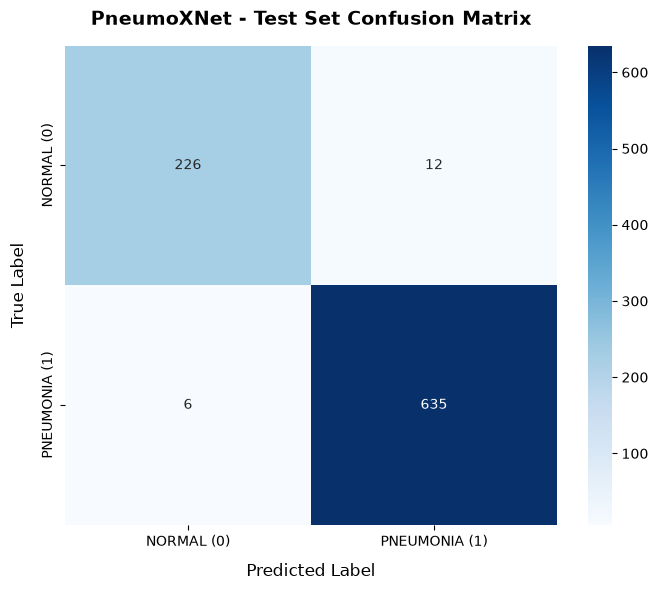

In [73]:
# ============================================================
# Cell 7: Visualizing Confusion Matrix
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
cm = confusion_matrix(binary_true, binary_preds)

# Plotting
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=['NORMAL (0)', 'PNEUMONIA (1)'],
    yticklabels=['NORMAL (0)', 'PNEUMONIA (1)']
)

plt.title('PneumoXNet - Test Set Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()